<a href="https://colab.research.google.com/github/Anhthu-2804/63135615_Web2/blob/main/notebooks/model_playground.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Environment

In [4]:
import os
import io
import time
import requests
import zipfile
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
import numpy as np
import torchvision.transforms as transforms
from PIL import Image

In [5]:
# clone the git repository and set it as the working directory
! git clone https://github.com/martin-marek/parking-space-occupancy
os.chdir('parking-space-occupancy')

Cloning into 'parking-space-occupancy'...
remote: Enumerating objects: 86, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 86 (delta 18), reused 17 (delta 17), pack-reused 60 (from 1)
Receiving objects: 100% (86/86), 3.58 MiB | 14.66 MiB/s, done.
Resolving deltas: 100% (36/36), done.


In [6]:
# download the dataset
if not os.path.exists('dataset/data'):
    r = requests.get("https://pub-e8bbdcbe8f6243b2a9933704a9b1d8bc.r2.dev/parking%2Frois_gopro.zip")
    z = zipfile.ZipFile(io.BytesIO(r.content))
    z.extractall('dataset/data')

# Visualize dataset

In [7]:
from dataset import acpds
from utils import transforms
from utils import visualize as vis

In [8]:
train_ds, valid_ds, test_ds = acpds.create_datasets('dataset/data')

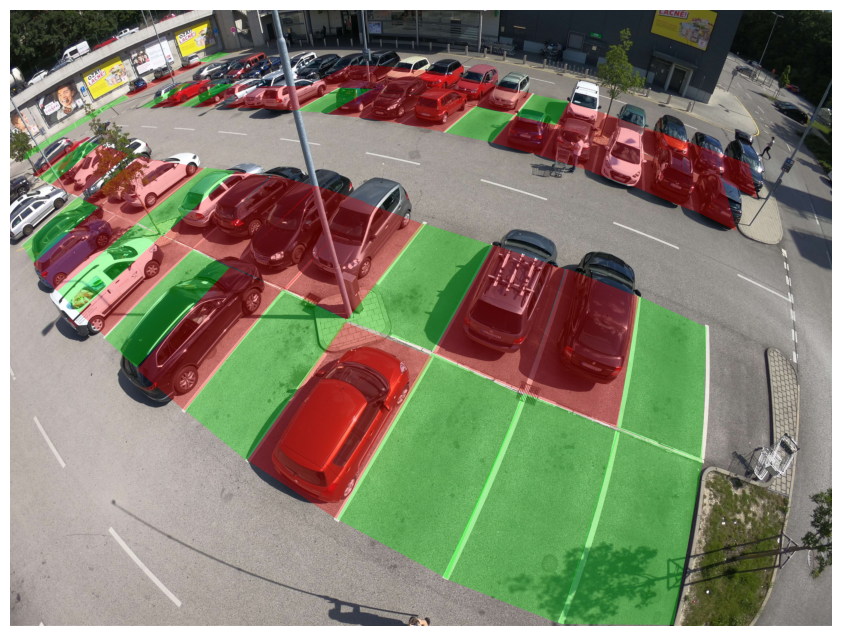

In [9]:
image_batch, rois_batch, labels_batch = next(iter(valid_ds))
image_raw, rois, labels = image_batch[0], rois_batch[0], labels_batch[0]
image = transforms.preprocess(image_raw, res=1440)
vis.plot_ds_image(image, rois, labels, show=True)

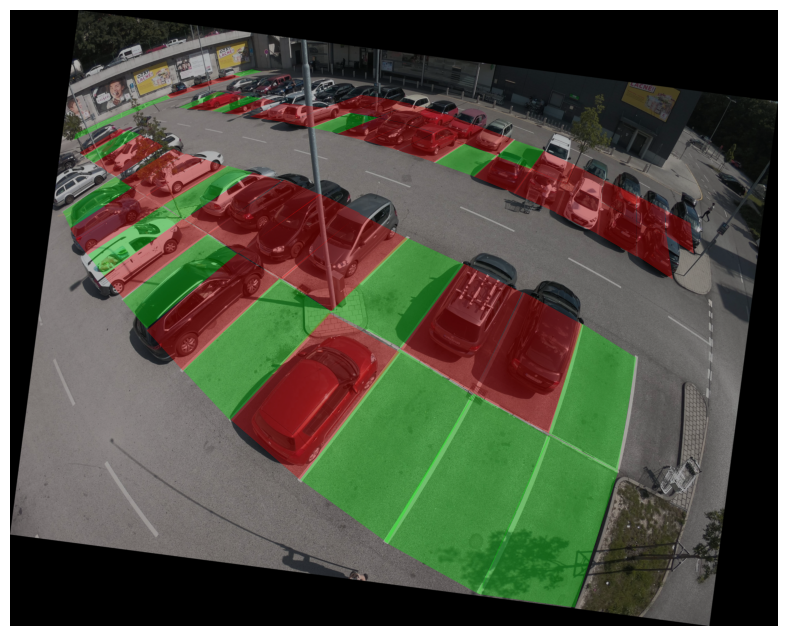

In [10]:
image_raw, rois, labels = image_batch[0], rois_batch[0], labels_batch[0]
image_aug, rois_aug = transforms.augment(image_raw, rois)
image_aug = transforms.preprocess(image_aug, res=1440)
vis.plot_ds_image(image_aug, rois_aug, labels, show=True)

# Plot model predictions

In [16]:
import matplotlib.pyplot as plt

In [11]:
from google.colab import files
uploaded = files.upload()


Saving video.mp4 to video.mp4


In [12]:
# Đọc video
video_path = 'video.mp4'
cap = cv2.VideoCapture(video_path)

In [13]:
# create model
from models.rcnn import RCNN
model = RCNN()

# load model weights
weights_path = 'weights.pt'
if not os.path.exists(weights_path):
    r = requests.get('https://pub-e8bbdcbe8f6243b2a9933704a9b1d8bc.r2.dev/parking%2FRCNN_128_square_gopro.pt')
    with open(weights_path, 'wb') as f:
        f.write(r.content)
model.load_state_dict(torch.load(weights_path, map_location='cpu'))

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 132MB/s]


<All keys matched successfully>

In [19]:

# Tải mô hình và trọng số
model = RCNN()

weights_path = 'weights.pt'
if not os.path.exists(weights_path):
    r = requests.get('https://pub-e8bbdcbe8f6243b2a9933704a9b1d8bc.r2.dev/parking%2FRCNN_128_square_gopro.pt')
    with open(weights_path, 'wb') as f:
        f.write(r.content)
model.load_state_dict(torch.load(weights_path, map_location='cpu'))

# Video input (đường dẫn video của bạn)
video_path = 'video.mp4'  # Đường dẫn video
cap = cv2.VideoCapture(video_path)

# Tiền xử lý ảnh
def preprocess(image, res=1440):
    # Chuyển đổi ảnh từ BGR (OpenCV) sang RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    # Resize ảnh nếu cần thiết
    image = cv2.resize(image, (res, res))
    image = np.transpose(image, (2, 0, 1))  # (H, W, C) -> (C, H, W)
    image = torch.tensor(image, dtype=torch.float32) / 255.0  # Chuẩn hóa
    image = image.unsqueeze(0)  # Thêm batch dimension
    return image

# Hàm hiển thị kết quả
def plot_results(image, rois, class_scores, labels):
    plt.imshow(image)
    for i, roi in enumerate(rois):
        if class_scores[i] > 0.5:  # Ngưỡng xác suất để quyết định có xe đậu hay không
            plt.plot([roi[0], roi[2]], [roi[1], roi[1]], color='red')  # Dọc
            plt.plot([roi[0], roi[2]], [roi[3], roi[3]], color='red')  # Dọc
            plt.plot([roi[0], roi[0]], [roi[1], roi[3]], color='red')  # Ngang
            plt.plot([roi[2], roi[2]], [roi[1], roi[3]], color='red')  # Ngang
    plt.show()

# Xử lý từng frame của video
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Tiền xử lý ảnh
    image = preprocess(frame)

    # Tạo vùng rois giả để chạy mô hình
    # (Giả sử mô hình yêu cầu rois có hình dạng [batch_size, num_rois, 4])
    rois = torch.tensor([[[0, 0, frame.shape[1], frame.shape[0]]]], dtype=torch.float32)  # Tạo một vùng bao phủ toàn bộ ảnh

    # Dự đoán với mô hình
    with torch.no_grad():
        # Dự đoán với model
        class_logits = model(image, rois)  # Truyền cả ảnh và rois
        rois = class_logits['rois']  # Vùng phát hiện (bounding boxes)
        class_scores = class_logits.softmax(1)[:, 1]  # Xác suất cho class 1 (xe)

    # Hiển thị kết quả
    plot_results(frame, rois, class_scores, labels=None)

    # Dừng video sau khi xử lý 100 frame (hoặc bạn có thể bỏ qua điều này để video chạy liên tục)
    if cv2.waitKey(1) & 0xFF == ord('q'):  # Nhấn 'q' để thoát
        break

cap.release()
cv2.destroyAllWindows()

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


RuntimeError: The following operation failed in the TorchScript interpreter.
Traceback of TorchScript (most recent call last):
  File "/content/parking-space-occupancy/models/utils/pooling.py", line 104, in roi_pool
    
    # gather the values indexed by the ROI grids
    warps = torch.stack([grid_sample(tensor[None], r[None], align_corners=True)[0] for r in rois_interpolated])
                         ~~~~~~~~~~~ <--- HERE
    
    return warps
  File "/usr/local/lib/python3.11/dist-packages/torch/nn/functional.py", line 5023, in grid_sample
        align_corners = False

    return torch.grid_sampler(input, grid, mode_enum, padding_mode_enum, align_corners)
           ~~~~~~~~~~~~~~~~~~ <--- HERE
RuntimeError: grid_sampler(): expected grid to have size 3 in last dimension, but got grid with sizes [1, 100, 100, 4]


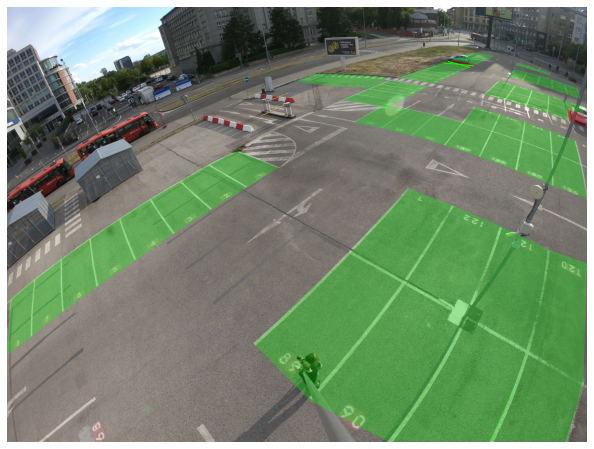

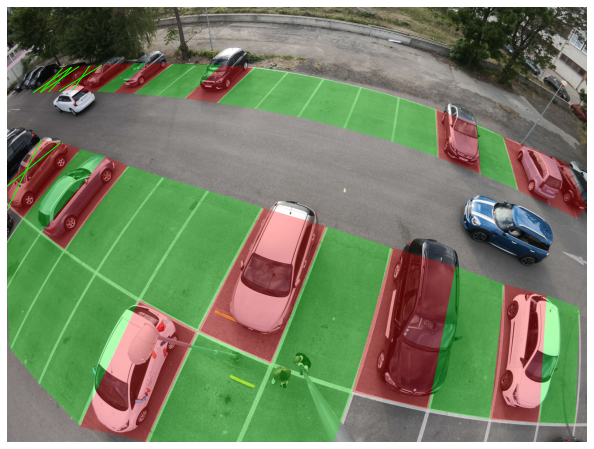

In [ ]:
# plot test predictions
for i, (image_batch, rois_batch, labels_batch) in enumerate(test_ds):
    if i == 2: break
    image, rois, labels = image_batch[0], rois_batch[0], labels_batch[0]
    image = transforms.preprocess(image)
    with torch.no_grad():
        class_logits = model(image, rois)
        class_scores = class_logits.softmax(1)[:, 1]
    vis.plot_ds_image(image, rois, class_scores, labels)

# Plot ROI warps

In [ ]:
from models.utils import pooling

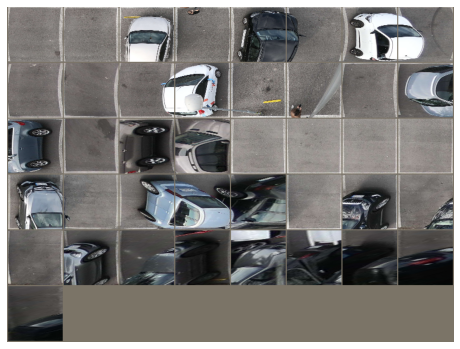

In [ ]:
warps = pooling.roi_pool(image, rois, 100, 'qdrl')
vis.show_warps(warps)

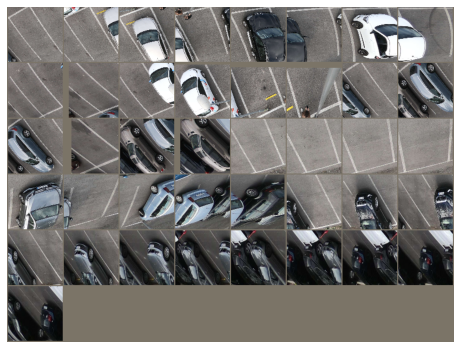

In [ ]:
warps = pooling.roi_pool(image, rois, 100, 'square')
vis.show_warps(warps)

# Speed comparison

In [ ]:
from models.rcnn import RCNN
from models.faster_rcnn_fpn import FasterRCNN_FPN

In [ ]:
def time_model(model, res=[1920, 1440], n=3):
    image = torch.zeros([3, res[1], res[0]])
    L_arr = torch.linspace(1, 100, steps=10, dtype=torch.int32)
    mean = np.zeros_like(L_arr, dtype=np.float32)
    ese = np.zeros_like(L_arr, dtype=np.float32)
    for i, L in enumerate(L_arr):
        times = np.zeros(n)
        for j in range(n):
            rois = torch.rand([L, 4, 2])
            t0 = time.time()
            out = model(image, rois)
            t1 = time.time()
            times[j] = t1 - t0
        mean[i] = np.mean(times)
        ese[i] = np.std(times) / np.sqrt(len(times))
    return L_arr, mean, ese

In [ ]:
times = {}
times['R-CNN (64)']  = time_model(RCNN(roi_res=64),  res=[4000, 3000])
times['R-CNN (128)'] = time_model(RCNN(roi_res=128), res=[4000, 3000])
times['R-CNN (256)'] = time_model(RCNN(roi_res=256), res=[4000, 3000])
times['Faster R-CNN FPN (800)']   = time_model(FasterRCNN_FPN(), res=[1067, 800])
times['Faster R-CNN FPN (1100)']  = time_model(FasterRCNN_FPN(), res=[1467, 1100])
times['Faster R-CNN FPN (1440)']  = time_model(FasterRCNN_FPN(), res=[1920, 1440])

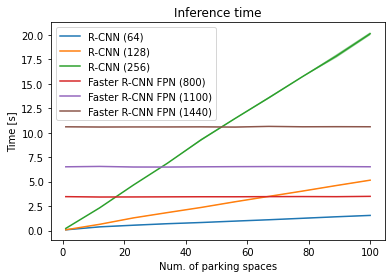

In [ ]:
for k, v in times.items():
    plt.plot(v[0], v[1], label=k)
    plt.fill_between(v[0], v[1]-v[2], v[1]+v[2], alpha=0.5)

plt.title('Inference time')
plt.xlabel('Num. of parking spaces')
plt.ylabel('Time [s]')
plt.legend()
plt.show()

# FPN level resolutions

In [ ]:
from torchvision.models.detection.backbone_utils import resnet_fpn_backbone
backbone = resnet_fpn_backbone('resnet50', pretrained=False)
image = torch.zeros([3, 1920, 1440])
out = backbone.body(image[None])
for k, v in out.items():
    print(k, v.shape)

0 torch.Size([1, 256, 480, 360])
1 torch.Size([1, 512, 240, 180])
2 torch.Size([1, 1024, 120, 90])
3 torch.Size([1, 2048, 60, 45])
